# Tweets Using BERT for Sentiment Analysis

### 1. IMPORT LIBRARIES


In [12]:

import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")


### 2. LOAD DATA

In [13]:


df = pd.read_csv("/kaggle/input/datasets/luckysingh7220/tweetsl/Tweets (1).csv")

# Clean column names
df.columns = df.columns.str.strip()

print("Columns:", df.columns)
df.head()

Columns: Index(['textID', 'text', 'selected_text', 'sentiment'], dtype='object')


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


### 3. PREPROCESS DATA

In [14]:
TEXT_COL = "selected_text"
LABEL_COL = "sentiment"

# Drop missing values
df = df[[TEXT_COL, LABEL_COL]].dropna()

#OPTIONAL: reduce size if training is slow
df = df.sample(2000)

texts = df[TEXT_COL].astype(str).tolist()

# 3-class mapping
label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

labels = [label_map[x] for x in df[LABEL_COL]]



### 4. TOKENIZATION

In [15]:

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

encodings = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=64,    # tweets are short
    return_tensors="pt"
)

### 5. DATASET CLASS

In [16]:

class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

dataset = TweetDataset(encodings, labels)


### 6. DATALOADER

In [17]:

loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)


model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3,
    output_attentions=True
)

optimizer = AdamW(model.parameters(), lr=2e-5)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### 8. TRAINING LOOP

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(device)

cuda


In [19]:

for epoch in range(3):
    model.train()
    total_loss = 0

    for i, batch in enumerate(loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Final Loss: {total_loss/len(loader):.4f}")


Epoch 1 Final Loss: 0.8098
Epoch 2 Final Loss: 0.3764
Epoch 3 Final Loss: 0.2159


### 9. ATTENTION VISUALIZATION

In [20]:


def visualize_attention(text):
    model.eval()

    inputs = tokenizer(text, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    attentions = outputs.attentions

    # Last layer, first head
    attention = attentions[-1][0][0].cpu().numpy()

    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    plt.figure(figsize=(10,8))
    sns.heatmap(attention, xticklabels=tokens, yticklabels=tokens, annot=True, cmap="viridis")
    plt.title("Attention Heatmap")
    plt.xticks(rotation=90)
    plt.show()


### 10. PREDICTION FUNCTION

In [21]:

label_names = {0: "negative", 1: "neutral", 2: "positive"}

def predict(text):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    pred = torch.argmax(logits, dim=1).item()

    print("Text:", text)
    print("Predicted Sentiment:", label_names[pred])


### 11. TEST

Text: The service was excellent and the staff were very friendly
Predicted Sentiment: positive


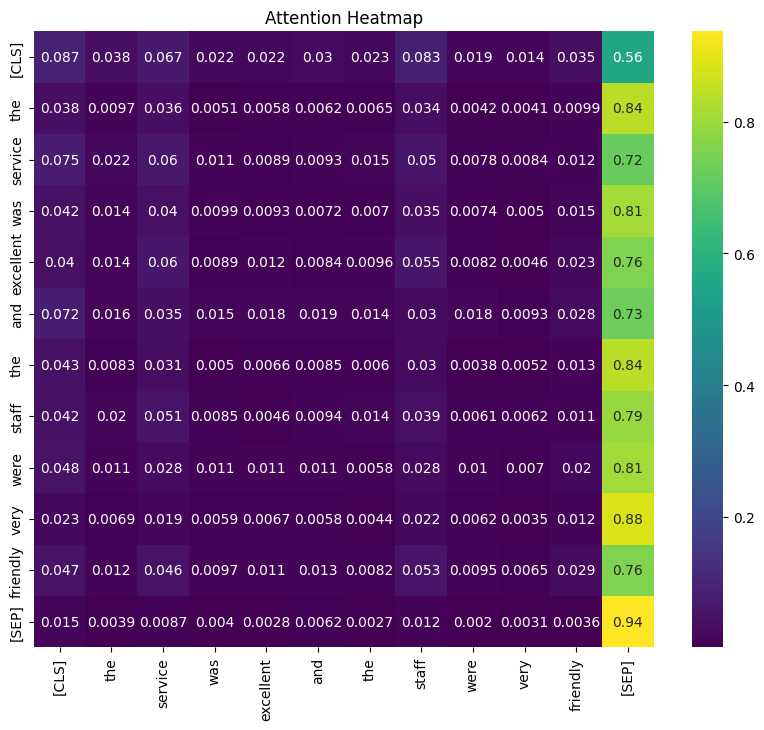

In [26]:

test_tweet = "The service was excellent and the staff were very friendly"

predict(test_tweet)
visualize_attention(test_tweet)
